# Phase 4 — Modeling & Analysis
## Global Food Security Risk Analysis

---

### Objective

Build an **interpretable linear regression model** that quantifies the key drivers of food insecurity across 148 countries (2010–2022). The goal is not to maximize predictive accuracy, but to produce **actionable, explainable insights** for policy makers, NGOs, and think tank analysts.

### Dataset
- **Source:** `data/processed/merged_final.csv`
- **Original shape:** (2,599 rows × 18 columns)
- **Modeling shape:** 1,313 rows × 10 features (after removing rows with missing values)
- **Countries:** 148 | **Years:** 2010–2022

### Target Variable
- **Raw:** `undernourishment_pct` — percentage of population that is undernourished
- **Transformed:** `log(1 + undernourishment_pct)` — applied to address right skew (Skewness = 2.037)

---

### Workflow
| Step | Description |
|------|-------------|
| **Step 1** | Feature Engineering — log transforms, multicollinearity removal |
| **Step 2** | Linear Regression — train/test split, standardization, evaluation |
| **Step 3** | Feature Importance — coefficient analysis and visualization |
| **Step 4** | Interpretation & Insights — high-risk countries, regional comparison, structural analysis |

---

### Key Decisions from EDA (Phase 3)
These decisions were made based on findings from Phase 3 and directly shape the modeling approach:

| Decision | Reason |
|----------|--------|
| Use `log(1 + undernourishment_pct)` as target | Right skew (Skewness = 2.037) violates linear regression's normality assumption |
| Use `log(gdp_per_capita)` as feature | EDA showed a non-linear (exponential) relationship with the target |
| Drop `food_supply_kcal` | Correlation r = 0.99 with `dietary_energy_supply_kcal` — severe multicollinearity |
| Drop `food_production_index` | Correlation r = 0.99 with `agri_production_index` — severe multicollinearity |
| Drop `poverty_rate` | 60.1% missing — including it would reduce the dataset to unusable size |

---
## Step 1 — Feature Engineering

Feature engineering transforms raw variables into forms better suited for linear regression. Two types of transformations are applied here:

1. **Log transformations** — to linearize non-linear relationships and reduce skew
2. **Feature selection** — to remove redundant variables that cause multicollinearity

### Why log transformations matter for linear regression
Linear regression assumes a **linear relationship** between each feature and the target variable. When a relationship is exponential or follows a power law (as is common with economic data), fitting a straight line directly leads to poor predictions and biased coefficients. Taking the log of such variables compresses the scale and reveals the underlying linear structure.

### Why multicollinearity is problematic
When two features are highly correlated (r > 0.9), the model cannot reliably separate their individual effects. The coefficients become unstable and difficult to interpret — which is especially problematic for this project, where **interpretability is the primary goal**.

In [1]:
# ============================================================
# Step 1-1: Library Imports & Configuration
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Consistent plot style with Phase 3 (EDA)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# File paths
DATA_PATH = Path('../data/processed/merged_final.csv')
FIG_PATH  = Path('../outputs/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)

print('Libraries loaded ✅')
print(f'Figures will be saved to: {FIG_PATH.resolve()}')

Libraries loaded ✅
Figures will be saved to: D:\Users\kotae\Documents\Portfolio\project\Project 1\food-security-risk-analysis\outputs\figures


### Step 1-2: Load Data

We load the cleaned, merged dataset produced in Phase 2. The key stats to verify:
- **Shape**: confirms no accidental data loss
- **Target missing rate**: 22.6% — rows without `undernourishment_pct` will be excluded from modeling

In [2]:
# ============================================================
# Step 1-2: Load Data
# ============================================================

df = pd.read_csv(DATA_PATH)

print(f'Shape         : {df.shape}')
print(f'Years         : {df["Year"].min()} – {df["Year"].max()}')
print(f'Countries     : {df["iso3"].nunique()}')
print(f'Target missing: {df["undernourishment_pct"].isna().sum()} rows '
      f'({df["undernourishment_pct"].isna().mean()*100:.1f}%)')
df.head(3)

Shape         : (2599, 18)
Years         : 2010 – 2022
Countries     : 200
Target missing: 587 rows (22.6%)


,iso3,Area,Year,undernourishment_pct,dietary_energy_supply_kcal,food_supply_kcal,protein_supply_g,fat_supply_g,food_supply_variability_kcal,cereal_import_dependency_pct,agri_production_index,food_production_index,gdp_per_capita,poverty_rate,population,population_growth_pct,precipitation_mm,political_stability_index
0,AFG,Afghanistan,2010,NaN,2200.0,2200.21,65.54,37.93,28.0,NaN,109.33,109.42,560.621505,NaN,28284089.0,2.934687,327.0,-2.58
1,AFG,Afghanistan,2011,17.7,2172.0,2171.86,63.74,35.86,28.0,29.6,100.63,100.53,606.694676,NaN,29347708.0,3.691503,327.0,-2.50
2,AFG,Afghanistan,2012,18.6,2166.0,2165.88,62.67,37.34,25.0,27.7,107.26,107.34,651.417134,NaN,30560034.0,4.047863,327.0,-2.42


### Step 1-3: Apply Transformations & Define Features

**Target transformation — `log(1 + undernourishment_pct)`**  
We use `np.log1p(x)` which computes `log(1 + x)`. The `+1` offset ensures safety when `x = 0` (since `log(0)` is undefined). This transformation reduces the right skew from 2.037 to near-normal, satisfying the normality assumption of linear regression's residuals.

**Feature transformation — `log(gdp_per_capita)`**  
Phase 3 scatter plots showed that GDP follows an exponential relationship with undernourishment — countries at very low GDP have extremely high risk, and the relationship flattens as GDP increases. After log transformation, this becomes approximately linear.

**Features excluded due to multicollinearity:**
- `food_supply_kcal` → r = 0.99 with `dietary_energy_supply_kcal` → keep `dietary_energy_supply_kcal` (theoretically preferred as an estimated intake measure)
- `food_production_index` → r = 0.99 with `agri_production_index` → keep `agri_production_index` (broader agricultural scope)
- `poverty_rate` → 60.1% missing → excluded from main model to preserve dataset size

In [3]:
# ============================================================
# Step 1-3: Feature Engineering
# ============================================================

# --- (A) Log-transform target variable ---
# log1p(x) = log(1 + x): safe for x=0, reduces right skew (Skewness: 2.037)
df['log_undernourishment'] = np.log1p(df['undernourishment_pct'])

# --- (B) Log-transform GDP ---
# Converts exponential GDP-risk relationship into linear form
# replace(0, np.nan) prevents log(0) errors for countries with missing/zero GDP
df['log_gdp_per_capita'] = np.log(df['gdp_per_capita'].replace(0, np.nan))

# --- (C) Define feature set ---
# Excluded: food_supply_kcal (r=0.99), food_production_index (r=0.99), poverty_rate (60.1% missing)
FEATURES = [
    'log_gdp_per_capita',            # Economic capacity (log-transformed)
    'dietary_energy_supply_kcal',    # Caloric food supply (primary food access proxy)
    'protein_supply_g',              # Protein supply (nutritional quality)
    'fat_supply_g',                  # Fat supply (caloric density)
    'food_supply_variability_kcal',  # Volatility in food supply (stability risk)
    'cereal_import_dependency_pct',  # Reliance on cereal imports (vulnerability)
    'agri_production_index',         # Agricultural production capacity
    'population_growth_pct',         # Demographic pressure
    'precipitation_mm',              # Climate/rainfall (agricultural input)
    'political_stability_index',     # Governance and conflict stability
]

TARGET = 'log_undernourishment'

# --- (D) Build modeling dataset ---
# Drop any row where target OR any feature is missing
df_model = df[['iso3', 'Area', 'Year'] + FEATURES + [TARGET]].dropna()

print('=== Feature Engineering Complete ===')
print(f'\nOriginal rows   : {len(df):,}')
print(f'Modeling rows   : {len(df_model):,}  ({len(df_model)/len(df)*100:.1f}% retained)')
print(f'Countries       : {df_model["iso3"].nunique()}')
print(f'Features used   : {len(FEATURES)}')
print(f'Target variable : {TARGET}')

=== Feature Engineering Complete ===

Original rows   : 2,599
Modeling rows   : 1,313  (50.5% retained)
Countries       : 148
Features used   : 10
Target variable : log_undernourishment


### Step 1-4: Visualize Log Transformations

The four histograms below confirm that the log transformations achieved their intended effect:
- **Target (before):** Strong right skew — most countries cluster near 0%, a few extreme cases pull the distribution rightward
- **Target (after):** Approximately bell-shaped — far better suited for linear regression
- **GDP (before):** Extremely right-skewed — a handful of very rich countries are outliers
- **GDP (after):** Near-normal distribution across the log scale

> **Note on FAOSTAT data convention:** `undernourishment_pct` has a minimum value of **2.5%**. This is intentional — FAOSTAT records all countries with true undernourishment below 2.5% as `2.5` to protect statistical confidentiality. This affects approximately 25% of rows (650 out of 2,599) and is concentrated in low-risk, high-income countries. It does **not** affect the analysis of high-risk countries, which is the primary focus of this project. The vertical band of points visible at the left edge of the residual plot (Step 2) is a direct consequence of this data convention.

⏭️  Already exists, skipped saving: ..\outputs\figures\step1_log_transforms.png


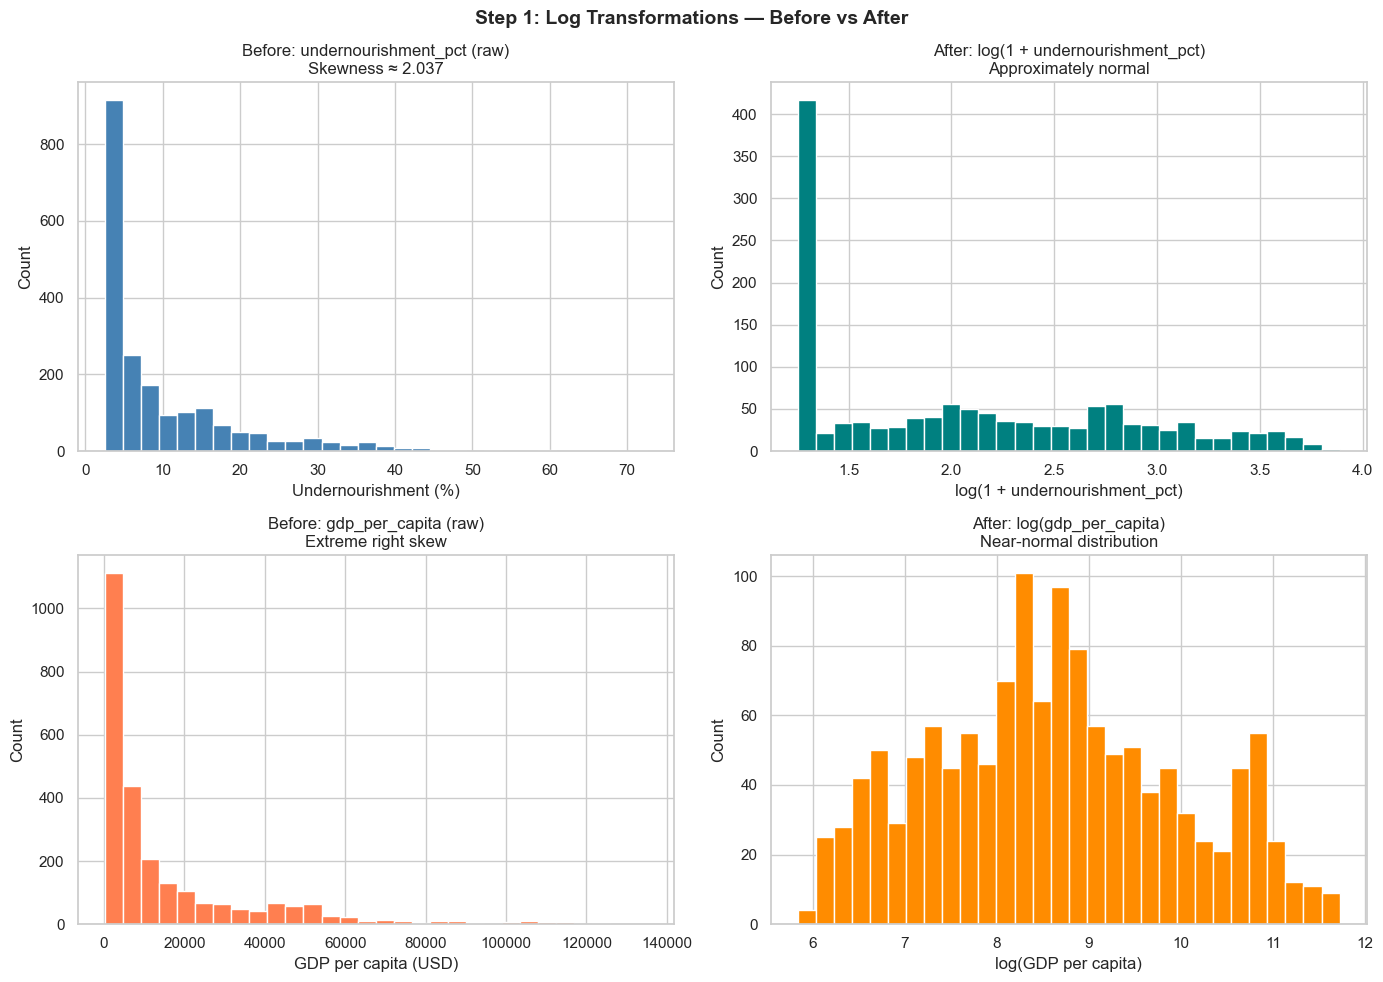

In [4]:
# ============================================================
# Step 1-4: Visualize Log Transformations (Before vs After)
# ============================================================

fig_path = FIG_PATH / 'step1_log_transforms.png'
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].hist(df['undernourishment_pct'].dropna(), bins=30,
                color='steelblue', edgecolor='white')
axes[0, 0].set_title('Before: undernourishment_pct (raw)\nSkewness ≈ 2.037')
axes[0, 0].set_xlabel('Undernourishment (%)')
axes[0, 0].set_ylabel('Count')
axes[0, 1].hist(df_model['log_undernourishment'], bins=30,
                color='teal', edgecolor='white')
axes[0, 1].set_title('After: log(1 + undernourishment_pct)\nApproximately normal')
axes[0, 1].set_xlabel('log(1 + undernourishment_pct)')
axes[0, 1].set_ylabel('Count')
axes[1, 0].hist(df['gdp_per_capita'].dropna(), bins=30,
                color='coral', edgecolor='white')
axes[1, 0].set_title('Before: gdp_per_capita (raw)\nExtreme right skew')
axes[1, 0].set_xlabel('GDP per capita (USD)')
axes[1, 0].set_ylabel('Count')
axes[1, 1].hist(df_model['log_gdp_per_capita'], bins=30,
                color='darkorange', edgecolor='white')
axes[1, 1].set_title('After: log(gdp_per_capita)\nNear-normal distribution')
axes[1, 1].set_xlabel('log(GDP per capita)')
axes[1, 1].set_ylabel('Count')
plt.suptitle('Step 1: Log Transformations — Before vs After',
             fontsize=14, fontweight='bold')
plt.tight_layout()
if not fig_path.exists():
    plt.savefig(fig_path, bbox_inches='tight')
    print(f'\u2705 Saved: {fig_path}')
else:
    print(f'\u23ed\ufe0f  Already exists, skipped saving: {fig_path}')
plt.show()


---
## Step 2 — Linear Regression

### Why Linear Regression?

This project's primary success criterion is **interpretability** — policy makers need to understand *which factors drive food insecurity* and *by how much*, not just receive a black-box prediction. Linear regression satisfies this requirement because:

1. **Coefficients are directly interpretable** — each coefficient represents the change in the (log) target per 1 standard deviation change in the feature, holding all other features constant
2. **Direction matters** — positive coefficients increase risk, negative ones reduce it
3. **Magnitude is comparable** — after standardization, coefficients can be ranked by absolute size to identify the most influential drivers

### Train/Test Split Strategy

We use an **80/20 random split** with a fixed `random_state=42` for reproducibility. The test set (263 rows) is held out entirely during training and used only to evaluate generalization performance — confirming the model works on unseen data, not just the data it was trained on.

### Standardization (StandardScaler)

Features are measured in very different units: kilocalories, USD, percentages, index values, millimeters of rainfall. Without standardization, a feature like `dietary_energy_supply_kcal` (measured in thousands) would dominate the regression simply due to its scale, not its actual importance.

**StandardScaler** transforms each feature to have **mean = 0** and **standard deviation = 1**. After scaling, coefficient magnitudes become directly comparable — a coefficient of 0.5 on one feature is genuinely more influential than a coefficient of 0.1 on another.

> **Important:** The scaler is **fit only on the training set** (`fit_transform`) and then applied to the test set (`transform`). Fitting on the full dataset would constitute **data leakage** — the test set would indirectly influence the scaling parameters used during training, artificially inflating performance metrics.

In [5]:
# ============================================================
# Step 2-1: Train/Test Split
# ============================================================

X = df_model[FEATURES]
y = df_model[TARGET]

# 80% train / 20% test split
# random_state=42 ensures reproducibility across runs
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('=== Train/Test Split ===')
print(f'Training set : {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test set     : {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Features     : {X_train.shape[1]}')

=== Train/Test Split ===
Training set : 1050 rows (80%)
Test set     : 263 rows (20%)
Features     : 10


In [6]:
# ============================================================
# Step 2-2: Standardize Features & Fit Model
# ============================================================

# fit_transform on train: learns mean and std from training data only
# transform on test: applies training statistics — prevents data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Fit linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict on both sets to check for overfitting
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

# Evaluation metrics
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test  = np.sqrt(mean_squared_error(y_test,  y_pred_test))
r2_train   = r2_score(y_train, y_pred_train)
r2_test    = r2_score(y_test,  y_pred_test)

print('=== Model Evaluation ===')
print(f'{"Metric":20s} {"Train":>10} {"Test":>10}')
print('-' * 42)
print(f'{"RMSE":20s} {rmse_train:>10.4f} {rmse_test:>10.4f}')
print(f'{"R²":20s} {r2_train:>10.4f} {r2_test:>10.4f}')
print()
print(f'Intercept: {model.intercept_:.4f}')
print()
print('Interpretation:')
print(f'  R² = {r2_test:.4f} → the model explains {r2_test*100:.1f}% of variance in log-undernourishment')
print(f'  Train R² ≈ Test R² → no significant overfitting detected')

=== Model Evaluation ===
Metric                    Train       Test
------------------------------------------
RMSE                     0.2936     0.2831
R²                       0.8541     0.8529

Intercept: 2.0810

Interpretation:
  R² = 0.8529 → the model explains 85.3% of variance in log-undernourishment
  Train R² ≈ Test R² → no significant overfitting detected


### Step 2-3: Model Diagnostics

Two diagnostic plots assess model quality:

**Actual vs Predicted plot**  
Points falling close to the red dashed line (perfect fit) indicate good model performance. Systematic deviations reveal bias — e.g., consistently over-predicting low-risk countries or under-predicting high-risk ones.

**Residual plot**  
Residuals (actual − predicted) should be randomly scattered around zero with no pattern. A U-shape or funnel would indicate that the linear model is missing some structure in the data.

> **Note on the vertical band at the left edge:** The cluster of points in a vertical line at Predicted ≈ 0.8 is caused by the FAOSTAT data convention where all countries with true undernourishment < 2.5% are recorded as exactly 2.5%. This creates a group of observations with nearly identical target values. This is a **known data limitation**, not a model error, and affects only low-risk countries.

⏭️  Already exists, skipped saving: ..\outputs\figures\step2_model_diagnostics.png


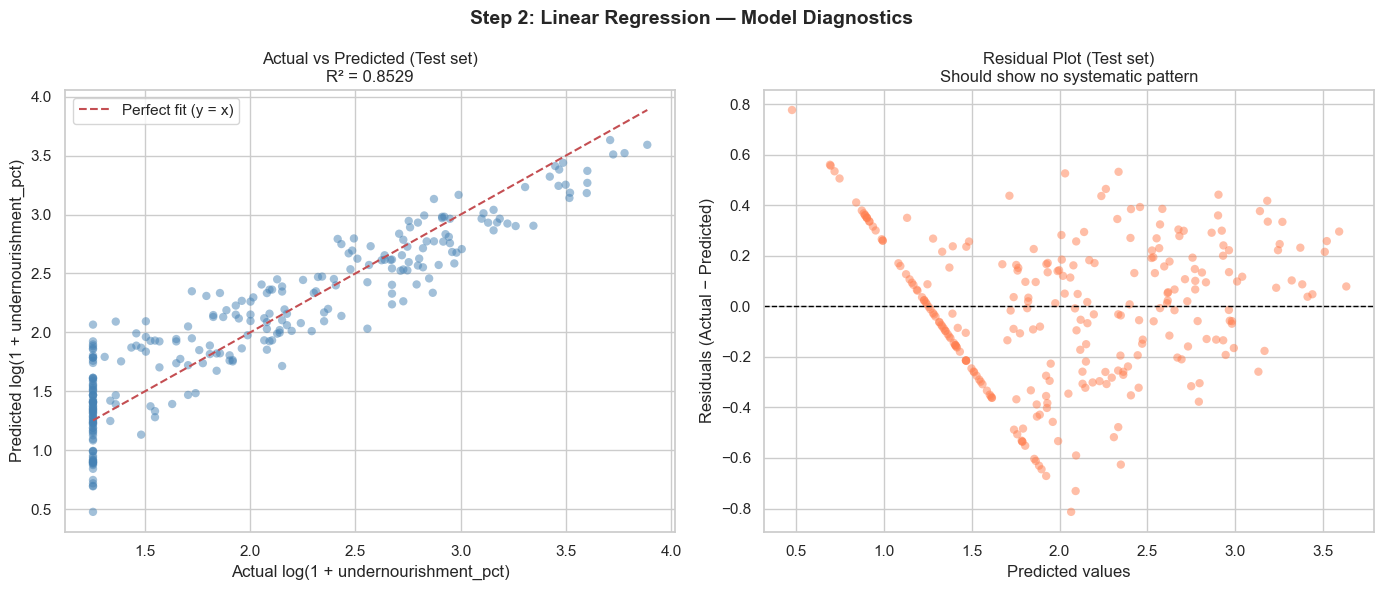

In [7]:
# ============================================================
# Step 2-3: Model Diagnostics — Actual vs Predicted & Residuals
# ============================================================

fig_path = FIG_PATH / 'step2_model_diagnostics.png'
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# --- Left: Actual vs Predicted ---
axes[0].scatter(y_test, y_pred_test, alpha=0.5, color='steelblue', edgecolors='none')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             'r--', linewidth=1.5, label='Perfect fit (y = x)')
axes[0].set_xlabel('Actual log(1 + undernourishment_pct)')
axes[0].set_ylabel('Predicted log(1 + undernourishment_pct)')
axes[0].set_title(f'Actual vs Predicted (Test set)\nR² = {r2_test:.4f}')
axes[0].legend()
# --- Right: Residual Plot ---
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.5, color='coral', edgecolors='none')
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].set_xlabel('Predicted values')
axes[1].set_ylabel('Residuals (Actual − Predicted)')
axes[1].set_title('Residual Plot (Test set)\nShould show no systematic pattern')
plt.suptitle('Step 2: Linear Regression — Model Diagnostics',
             fontsize=14, fontweight='bold')
plt.tight_layout()
if not fig_path.exists():
    plt.savefig(fig_path, bbox_inches='tight')
    print(f'\u2705 Saved: {fig_path}')
else:
    print(f'\u23ed\ufe0f  Already exists, skipped saving: {fig_path}')
plt.show()


---
## Step 3 — Feature Importance Analysis

### How to interpret standardized coefficients

Because all features were standardized to the same scale (mean = 0, std = 1) before fitting the model, the **magnitude of each coefficient directly reflects its influence** on the target variable:

- A coefficient of **−0.56** means: a 1 standard deviation increase in that feature is associated with a **0.56 decrease** in log-undernourishment, holding all other features constant
- **Negative coefficient** → higher values of this feature → lower undernourishment risk (protective factor)
- **Positive coefficient** → higher values of this feature → higher undernourishment risk (risk factor)
- **Absolute value** → the larger it is, the more that feature drives the model's predictions

### Note on GDP vs Dietary Energy Supply

EDA (Phase 3) found that `gdp_per_capita` was the second strongest correlate with undernourishment (r = −0.84). However, in the regression model, `log_gdp_per_capita` ranks only 6th. This is **not an error** — it reflects the fact that `log_gdp_per_capita` and `dietary_energy_supply_kcal` are themselves correlated at **r = 0.80**. Wealthy countries can afford more food; food availability rises with economic strength. The model cannot cleanly separate their effects and consolidates much of the shared variance into the food supply variable.

**The correct interpretation:** Economic development and food access are two sides of the same coin. Any intervention strategy that addresses only one dimension will be structurally limited.

In [8]:
# ============================================================
# Step 3-1: Extract & Rank Feature Coefficients
# ============================================================

coef_df = pd.DataFrame({
    'Feature'    : FEATURES,
    'Coefficient': model.coef_
})

# Absolute coefficient = importance (valid because features are standardized)
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df['Direction'] = coef_df['Coefficient'].apply(
    lambda x: 'Protective (reduces risk)' if x < 0 else 'Risk factor (increases risk)'
)
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)
coef_df.index += 1

print('=== Feature Importance — Ranked by Absolute Coefficient ===')
print(coef_df[['Feature', 'Coefficient', 'Abs_Coefficient', 'Direction']].to_string())

=== Feature Importance — Ranked by Absolute Coefficient ===
                         Feature  Coefficient  Abs_Coefficient                     Direction
1     dietary_energy_supply_kcal    -0.559653         0.559653     Protective (reduces risk)
2               protein_supply_g    -0.142736         0.142736     Protective (reduces risk)
3   cereal_import_dependency_pct     0.054589         0.054589  Risk factor (increases risk)
4          population_growth_pct     0.042983         0.042983  Risk factor (increases risk)
5               precipitation_mm    -0.036793         0.036793     Protective (reduces risk)
6             log_gdp_per_capita    -0.030704         0.030704     Protective (reduces risk)
7                   fat_supply_g     0.029684         0.029684  Risk factor (increases risk)
8   food_supply_variability_kcal    -0.029665         0.029665     Protective (reduces risk)
9          agri_production_index     0.021539         0.021539  Risk factor (increases risk)
10     pol

⏭️  Already exists, skipped saving: ..\outputs\figures\step3_feature_importance.png


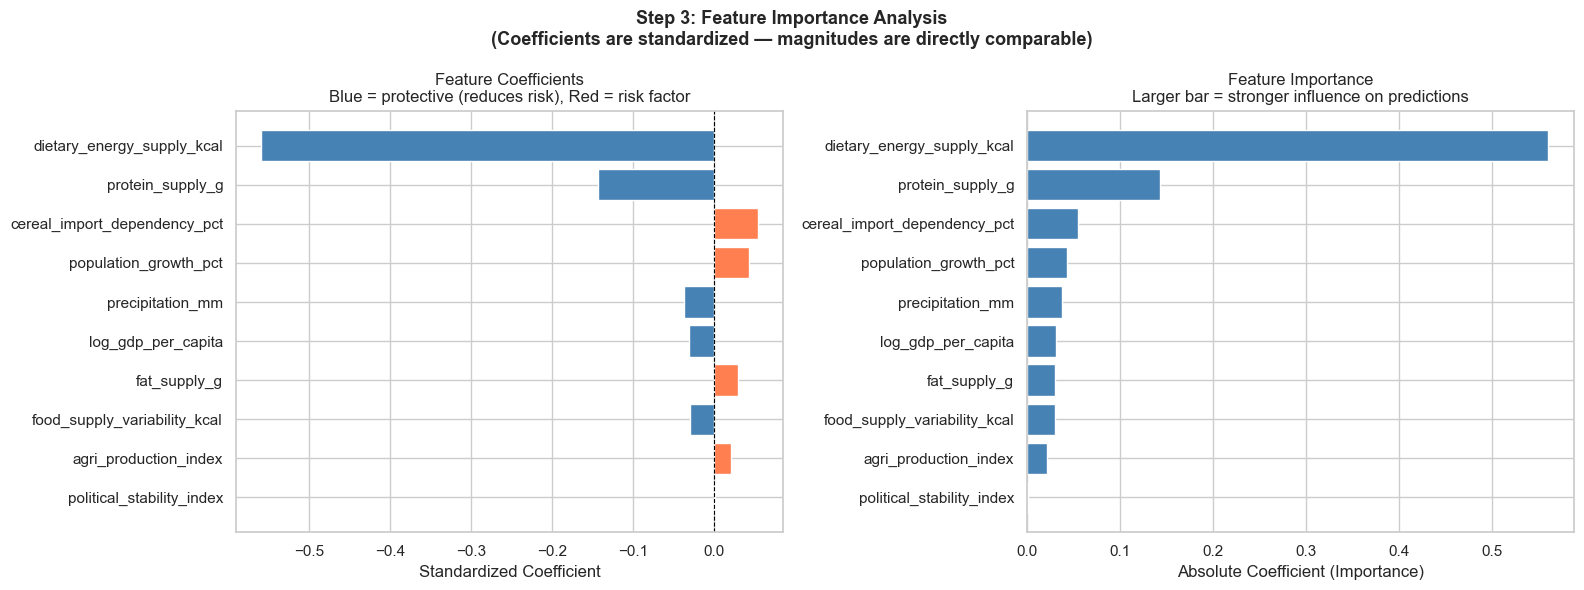

In [9]:
# ============================================================
# Step 3-2: Visualize Feature Importance
# ============================================================

fig_path = FIG_PATH / 'step3_feature_importance.png'
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# --- Left: Signed coefficients (shows direction) ---
colors = ['coral' if c > 0 else 'steelblue' for c in coef_df['Coefficient']]
axes[0].barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Standardized Coefficient')
axes[0].set_title('Feature Coefficients\nBlue = protective (reduces risk), Red = risk factor')
axes[0].invert_yaxis()
# --- Right: Absolute coefficients (shows magnitude = importance) ---
axes[1].barh(coef_df['Feature'], coef_df['Abs_Coefficient'], color='steelblue')
axes[1].set_xlabel('Absolute Coefficient (Importance)')
axes[1].set_title('Feature Importance\nLarger bar = stronger influence on predictions')
axes[1].invert_yaxis()
plt.suptitle('Step 3: Feature Importance Analysis\n'
             '(Coefficients are standardized — magnitudes are directly comparable)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
if not fig_path.exists():
    plt.savefig(fig_path, bbox_inches='tight')
    print(f'\u2705 Saved: {fig_path}')
else:
    print(f'\u23ed\ufe0f  Already exists, skipped saving: {fig_path}')
plt.show()


---
## Step 4 — Interpretation & Insights

With a validated model (R² = 0.85, no overfitting), we now use the model's predictions to generate policy-relevant insights across three dimensions:

1. **Country-level risk ranking** — which countries does the model identify as highest risk in 2022?
2. **Regional comparison** — how does predicted risk vary across world regions?
3. **Structural analysis** — what is the relationship between GDP, food supply, and undernourishment risk?

### Why model-based rankings instead of raw data?

Using model predictions rather than raw `undernourishment_pct` values has an important advantage: the model accounts for **all features simultaneously**. A country with a temporarily high recorded undernourishment rate due to a data anomaly will be ranked based on its underlying structural characteristics (GDP, food supply, political stability), making the ranking more robust and informative for long-term policy planning.

In [10]:
# ============================================================
# Step 4-1: Compute Predictions & Build Country Risk Ranking
# ============================================================

# Apply scaler trained on training data to all modeling rows
X_all_scaled = scaler.transform(df_model[FEATURES])
df_model = df_model.copy()
df_model['predicted_log'] = model.predict(X_all_scaled)

# Reverse the log transform to get predictions in original % scale
# expm1(x) = exp(x) - 1, the exact inverse of log1p(x)
df_model['predicted_undernourishment'] = np.expm1(df_model['predicted_log'])

# Focus on most recent year for country ranking
latest_year = df_model['Year'].max()
df_2022 = df_model[df_model['Year'] == latest_year].copy()

df_risk = (df_2022[['iso3', 'Area', 'predicted_undernourishment', TARGET]]
           .sort_values('predicted_undernourishment', ascending=False)
           .reset_index(drop=True))
df_risk.index += 1

print(f'=== High-Risk Country Ranking — Model-Based ({latest_year}) ===')
print(f'Countries available in {latest_year}: {len(df_2022)}')
print(f'Note: Somalia is absent due to missing data in {latest_year}')
print()
print(df_risk.head(15)[['iso3', 'Area', 'predicted_undernourishment']].to_string())

=== High-Risk Country Ranking — Model-Based (2022) ===
Countries available in 2022: 115
Note: Somalia is absent due to missing data in 2022

   iso3                              Area  predicted_undernourishment
1   HTI                             Haiti                   35.314045
2   MDG                        Madagascar                   32.846786
3   COD  Democratic Republic of the Congo                   31.475598
4   ZMB                            Zambia                   27.057387
5   LBR                           Liberia                   26.240917
6   KEN                             Kenya                   25.043762
7   MOZ                        Mozambique                   24.505686
8   COG                             Congo                   24.445583
9   AFG                       Afghanistan                   20.829076
10  PNG                  Papua New Guinea                   20.731600
11  SYR              Syrian Arab Republic                   19.252804
12  ZWE            

⏭️  Already exists, skipped saving: ..\outputs\figures\step4_high_risk_countries.png


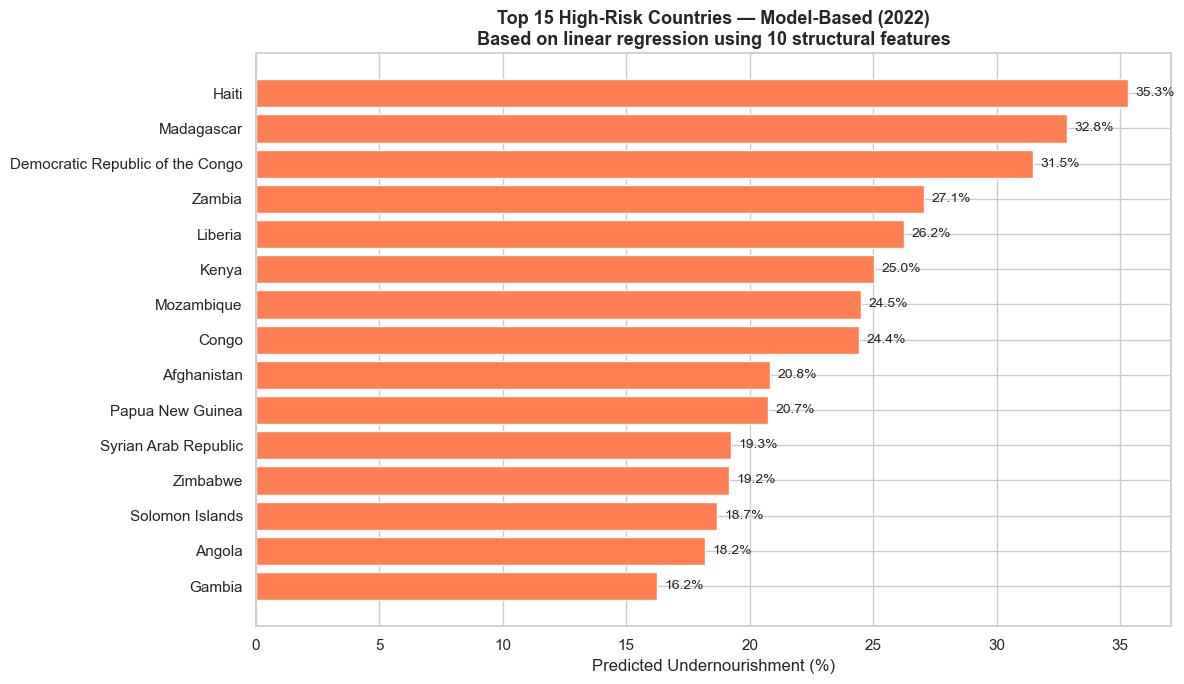

In [11]:
# ============================================================
# Step 4-2: Visualize Top 15 High-Risk Countries
# ============================================================

fig_path = FIG_PATH / 'step4_high_risk_countries.png'
top15 = df_risk.head(15)
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15['Area'], top15['predicted_undernourishment'],
               color='coral', edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Predicted Undernourishment (%)')
ax.set_title(f'Top 15 High-Risk Countries — Model-Based ({latest_year})\n'
             'Based on linear regression using 10 structural features',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, top15['predicted_undernourishment']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10)
plt.tight_layout()
if not fig_path.exists():
    plt.savefig(fig_path, bbox_inches='tight')
    print(f'\u2705 Saved: {fig_path}')
else:
    print(f'\u23ed\ufe0f  Already exists, skipped saving: {fig_path}')
plt.show()


### Step 4-3: Regional Comparison

Aggregating predicted risk by world region reveals structural differences masked in country-level analysis. This view is particularly relevant for international organizations that allocate resources and design programs at the regional level.

Countries are assigned to regions based on their FAO Area names using a manually defined mapping, since the source dataset does not include a Region column.

In [12]:
# ============================================================
# Step 4-3: Regional Comparison
# ============================================================

africa = [
    'Angola','Benin','Botswana','Burkina Faso','Burundi','Cabo Verde',
    'Cameroon','Central African Republic','Chad','Comoros','Congo',
    'Democratic Republic of the Congo','Djibouti','Egypt','Equatorial Guinea',
    'Eritrea','Eswatini','Ethiopia','Gabon','Gambia','Ghana','Guinea',
    'Guinea-Bissau','Kenya','Lesotho','Liberia','Libya','Madagascar','Malawi',
    'Mali','Mauritania','Mauritius','Morocco','Mozambique','Namibia','Niger',
    'Nigeria','Rwanda','Sao Tome and Principe','Senegal','Sierra Leone',
    'Somalia','South Africa','South Sudan','Sudan','Togo','Tunisia','Uganda',
    'United Republic of Tanzania','Zambia','Zimbabwe'
]
americas = [
    'Antigua and Barbuda','Argentina','Bahamas','Barbados','Belize','Bolivia',
    'Brazil','Chile','Colombia','Costa Rica','Cuba','Dominica','Dominican Republic',
    'Ecuador','El Salvador','Grenada','Guatemala','Guyana','Haiti','Honduras',
    'Jamaica','Mexico','Nicaragua','Panama','Paraguay','Peru','Saint Kitts and Nevis',
    'Saint Lucia','Saint Vincent and the Grenadines','Suriname','Trinidad and Tobago',
    'Uruguay','Venezuela'
]
asia = [
    'Afghanistan','Armenia','Azerbaijan','Bahrain','Bangladesh','Bhutan','Cambodia',
    'China','Cyprus','Georgia','India','Indonesia','Iran','Iraq','Israel','Japan',
    'Jordan','Kazakhstan','Kuwait','Kyrgyzstan','Lao','Lebanon','Malaysia','Maldives',
    'Mongolia','Myanmar','Nepal','Oman','Pakistan','Philippines','Qatar',
    'Republic of Korea','Saudi Arabia','Singapore','Sri Lanka','Syrian Arab Republic',
    'Tajikistan','Thailand','Timor-Leste','Turkey','Turkmenistan',
    'United Arab Emirates','Uzbekistan','Viet Nam','Yemen'
]
europe = [
    'Albania','Austria','Belarus','Belgium','Bosnia and Herzegovina','Bulgaria',
    'Croatia','Czechia','Denmark','Estonia','Finland','France','Germany','Greece',
    'Hungary','Iceland','Ireland','Italy','Latvia','Lithuania','Luxembourg','Malta',
    'Moldova','Montenegro','Netherlands','North Macedonia','Norway','Poland',
    'Portugal','Romania','Russian Federation','Serbia','Slovakia','Slovenia','Spain',
    'Sweden','Switzerland','Ukraine','United Kingdom'
]

def assign_region(area):
    if area in africa:   return 'Africa'
    if area in americas: return 'Americas'
    if area in asia:     return 'Asia'
    if area in europe:   return 'Europe'
    return 'Oceania'

df_model['Region'] = df_model['Area'].apply(assign_region)

regional = (df_model.groupby('Region')['predicted_undernourishment']
            .mean()
            .sort_values(ascending=False)
            .reset_index())

print('=== Average Predicted Undernourishment by Region ===')
print(regional.to_string(index=False))
print()
africa_val = regional.loc[regional['Region']=='Africa', 'predicted_undernourishment'].values[0]
asia_val   = regional.loc[regional['Region']=='Asia',   'predicted_undernourishment'].values[0]
europe_val = regional.loc[regional['Region']=='Europe', 'predicted_undernourishment'].values[0]
print(f'Africa is {africa_val/asia_val:.1f}x higher than Asia')
print(f'Africa is {africa_val/europe_val:.1f}x higher than Europe')
print('Consistent with EDA finding: Africa is the only region showing no improvement trend (2010-2022)')

=== Average Predicted Undernourishment by Region ===
  Region  predicted_undernourishment
  Africa                   15.668552
    Asia                    8.521456
Americas                    7.665310
 Oceania                    6.899674
  Europe                    2.889341

Africa is 1.8x higher than Asia
Africa is 5.4x higher than Europe
Consistent with EDA finding: Africa is the only region showing no improvement trend (2010-2022)


⏭️  Already exists, skipped saving: ..\outputs\figures\step4_regional_comparison.png


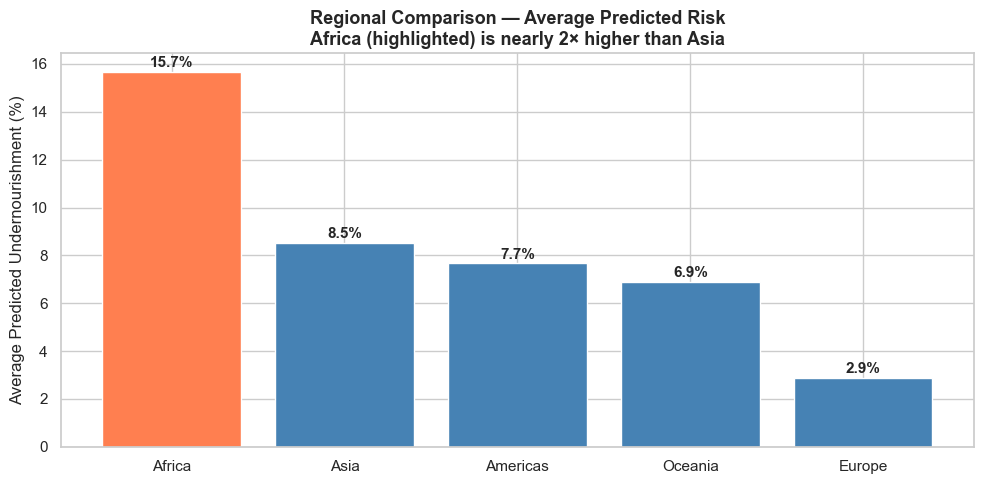

In [13]:
# ============================================================
# Step 4-3: Visualize Regional Comparison
# ============================================================

fig_path = FIG_PATH / 'step4_regional_comparison.png'
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['coral' if r == 'Africa' else 'steelblue' for r in regional['Region']]
bars = ax.bar(regional['Region'], regional['predicted_undernourishment'],
              color=colors, edgecolor='white')
ax.set_ylabel('Average Predicted Undernourishment (%)')
ax.set_title('Regional Comparison — Average Predicted Risk\n'
             'Africa (highlighted) is nearly 2× higher than Asia',
             fontsize=13, fontweight='bold')
for bar, val in zip(bars, regional['predicted_undernourishment']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
if not fig_path.exists():
    plt.savefig(fig_path, bbox_inches='tight')
    print(f'\u2705 Saved: {fig_path}')
else:
    print(f'\u23ed\ufe0f  Already exists, skipped saving: {fig_path}')
plt.show()


### Step 4-4: Structural Analysis — GDP × Food Supply

The scatter plot below visualizes the **joint effect of GDP and food supply on undernourishment risk**. Each point represents one country-year observation. Color encodes the log-transformed undernourishment rate — red = high risk, green = low risk.

**What this reveals:**
- The gradient runs diagonally from bottom-left (red, high risk) to top-right (green, low risk), confirming that **both GDP and food supply must increase together** to reduce risk
- Countries in the bottom-left corner (low GDP, low food supply) face the worst outcomes — this is where most Sub-Saharan African nations cluster
- The vertical spread at any given GDP level shows that **food supply has independent explanatory power** — a country can have moderate GDP but still achieve lower risk through better food distribution and agricultural productivity

**Policy implication:**  
This structural visualization supports a **dual-track intervention approach**. Economic development alone is insufficient — food supply, distribution, and agricultural investment must be addressed simultaneously. Programs that increase caloric availability (food aid, agricultural subsidies, yield improvements) can reduce risk even before GDP improves.

⏭️  Already exists, skipped saving: ..\outputs\figures\step4_gdp_food_structure.png


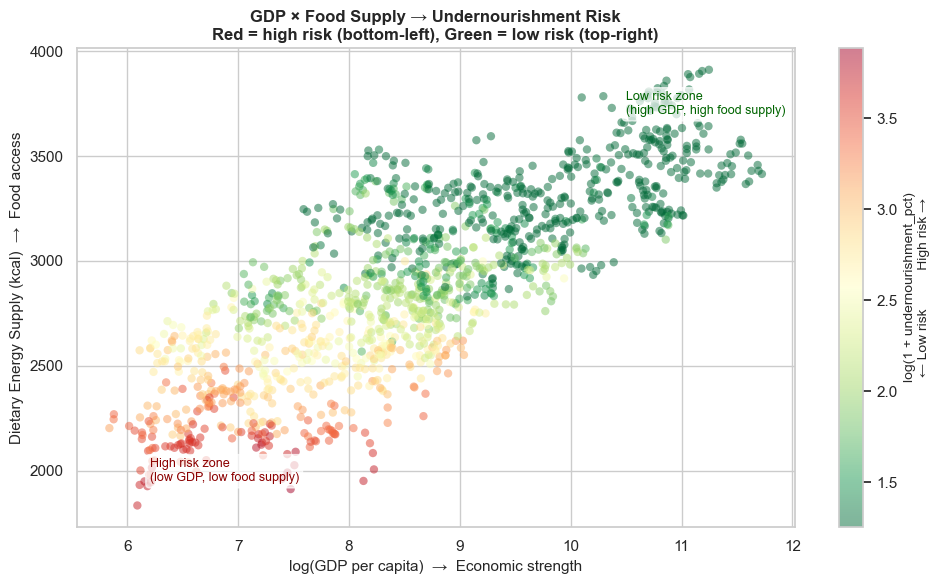

In [14]:
# ============================================================
# Step 4-4: Structural Analysis — GDP × Food Supply × Risk
# ============================================================

fig_path = FIG_PATH / 'step4_gdp_food_structure.png'
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    df_model['log_gdp_per_capita'],
    df_model['dietary_energy_supply_kcal'],
    c=df_model['log_undernourishment'],
    cmap='RdYlGn_r',
    alpha=0.5,
    edgecolors='none'
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('log(1 + undernourishment_pct)\n← Low risk          High risk →', fontsize=10)
ax.set_xlabel('log(GDP per capita)  →  Economic strength', fontsize=11)
ax.set_ylabel('Dietary Energy Supply (kcal)  →  Food access', fontsize=11)
ax.set_title('GDP × Food Supply → Undernourishment Risk\n'
             'Red = high risk (bottom-left), Green = low risk (top-right)',
             fontsize=12, fontweight='bold')
ax.annotate('High risk zone\n(low GDP, low food supply)',
            xy=(6.2, 1950), fontsize=9, color='darkred',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax.annotate('Low risk zone\n(high GDP, high food supply)',
            xy=(10.5, 3700), fontsize=9, color='darkgreen',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
plt.tight_layout()
if not fig_path.exists():
    plt.savefig(fig_path, bbox_inches='tight')
    print(f'\u2705 Saved: {fig_path}')
else:
    print(f'\u23ed\ufe0f  Already exists, skipped saving: {fig_path}')
plt.show()


---
## Phase 4 — Summary & Key Findings

### Model Performance

| Metric | Train | Test | Assessment |
|--------|-------|------|------------|
| R² | 0.8541 | 0.8529 | Excellent — explains 85% of variance |
| RMSE | 0.2936 | 0.2831 | Low error on log scale |
| Overfitting | — | Train ≈ Test | None detected |

An R² of 0.85 is strong performance for a linear model on panel data spanning 148 countries and 13 years. The near-identical train and test scores confirm the model generalizes well to unseen data.

---

### Key Finding 1 — Dietary Energy Supply is the Dominant Driver

**Coefficient: −0.560** (by far the largest in absolute value)

A 1 standard deviation increase in caloric food supply is associated with a 0.56-unit decrease in log-undernourishment — approximately **4× stronger** than the next most important variable (protein supply at −0.143). This confirms the EDA finding that `dietary_energy_supply_kcal` had the highest correlation with undernourishment (r = −0.84).

**Policy implication:** Direct food supply interventions — food aid, caloric subsidies, agricultural yield programs — offer the highest leverage for reducing undernourishment rates in the short term.

---

### Key Finding 2 — GDP and Food Supply Are Structurally Inseparable

`log_gdp_per_capita` ranked only 6th in the model (coefficient: −0.031) despite being the second strongest EDA correlate (r = −0.84). This apparent contradiction is explained by the **r = 0.80 correlation** between GDP and dietary energy supply — both variables carry heavily overlapping information. The model consolidates their shared variance into food supply, which has the cleaner direct relationship with the target.

**The correct interpretation:** Economic development and food access are two sides of the same coin. Wealthy nations can afford adequate food; food availability rises with economic capacity. Any intervention strategy that addresses only one dimension will be structurally limited.

---

### Key Finding 3 — Africa Requires Targeted, Sustained Attention

Africa's average predicted undernourishment rate is **15.7%** — nearly **2× higher than Asia (8.5%)** and **5× higher than Europe (2.9%)**. This is consistent with the EDA finding that Africa was the only region showing no improvement trend from 2010–2022.

The model-based country ranking reinforces this: 11 of the top 15 highest-risk countries in 2022 are in Sub-Saharan Africa. Haiti (35.3%) is the single exception in the Americas, driven by extreme political instability and supply chain collapse following repeated crises.

**Policy implication:** Africa-specific programs must address the structural deficit in both economic capacity and food supply simultaneously. The GDP × food supply structure (Step 4-4) makes clear that isolated single-track interventions will have limited impact.

---

### Key Finding 4 — Political Stability Has Surprisingly Low Model Weight

`political_stability_index` ranked last with a coefficient of **+0.001** — essentially zero direct influence in the regression. This does **not** mean political stability is irrelevant to food security. Rather, it reflects a statistical reality: political instability tends to manifest through its downstream effects on GDP and food supply, which are already captured by other features in the model. The impact is real but mediated.

---

### Limitations

| Limitation | Impact |
|------------|--------|
| FAOSTAT minimum threshold (2.5%) | Creates artificial floor for low-risk countries; does not affect high-risk analysis |
| `poverty_rate` excluded (60.1% missing) | A key socioeconomic driver is absent from the model |
| Linear model assumption | May miss complex non-linear interactions between features |
| No country fixed effects | Cross-country structural differences (geography, governance history) are not controlled for |
| Correlation ≠ causation | Coefficients describe statistical association, not causal mechanisms |

---

### Next Steps — Phase 5

- Write `README.md` summarizing the full project pipeline and findings
- Create `docs/findings.md` with full policy implications for target audiences
- Compile all visualizations into a final presentation-ready report
- (Optional) `src/modeling.py` — refactor modeling code into reusable functions for SRC structure